<a href="https://colab.research.google.com/github/Anchor-head/ScienceGenreClassification/blob/main/SetFit-SciBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!unzip model6.zip -d "./model6"

Archive:  model6.zip
   creating: ./model6/1_Pooling/
   creating: ./model6/2_Dense/
  inflating: ./model6/config_sentence_transformers.json  
  inflating: ./model6/vocab.txt      
  inflating: ./model6/README.md      
  inflating: ./model6/model.safetensors  
  inflating: ./model6/config_setfit.json  
  inflating: ./model6/sentence_bert_config.json  
  inflating: ./model6/tokenizer.json  
  inflating: ./model6/config.json    
  inflating: ./model6/tokenizer_config.json  
  inflating: ./model6/special_tokens_map.json  
  inflating: ./model6/modules.json   
  inflating: ./model6/model_head.pkl  
  inflating: ./model6/1_Pooling/config.json  
  inflating: ./model6/2_Dense/model.safetensors  
  inflating: ./model6/2_Dense/config.json  


In [1]:
!pip install "datasets>=2.15.0,<3.0.0"
!pip install setfit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.7.0
    Uninstalling fsspec-2025.7.0:
      Successfully uninstalled fsspec-2025.7.0
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.7.0 requires fsspec==2025.7.0, but you have fsspec 2024.6.1 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; plat

In [2]:
!pip install pandas
!pip install seaborn
!pip install matplotlib
!pip install scikit-learn

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with

                             precision    recall  f1-score   support

                Book Review       1.00      0.62      0.77         8
                 Correction       0.25      0.50      0.33         2
                  Editorial       0.00      0.00      0.00         2
                     Letter       0.64      0.82      0.72        22
                Miscellanea       0.40      0.86      0.55         7
            News Journalism       0.38      0.43      0.40         7
Policy, Science and Society       0.00      0.00      0.00         9
          Research Document       0.75      0.78      0.76        27
                 Retraction       0.00      0.00      0.00         1
       Societies and People       0.44      0.33      0.38        12

                   accuracy                           0.60        97
                  macro avg       0.39      0.43      0.39        97
               weighted avg       0.55      0.60      0.56        97



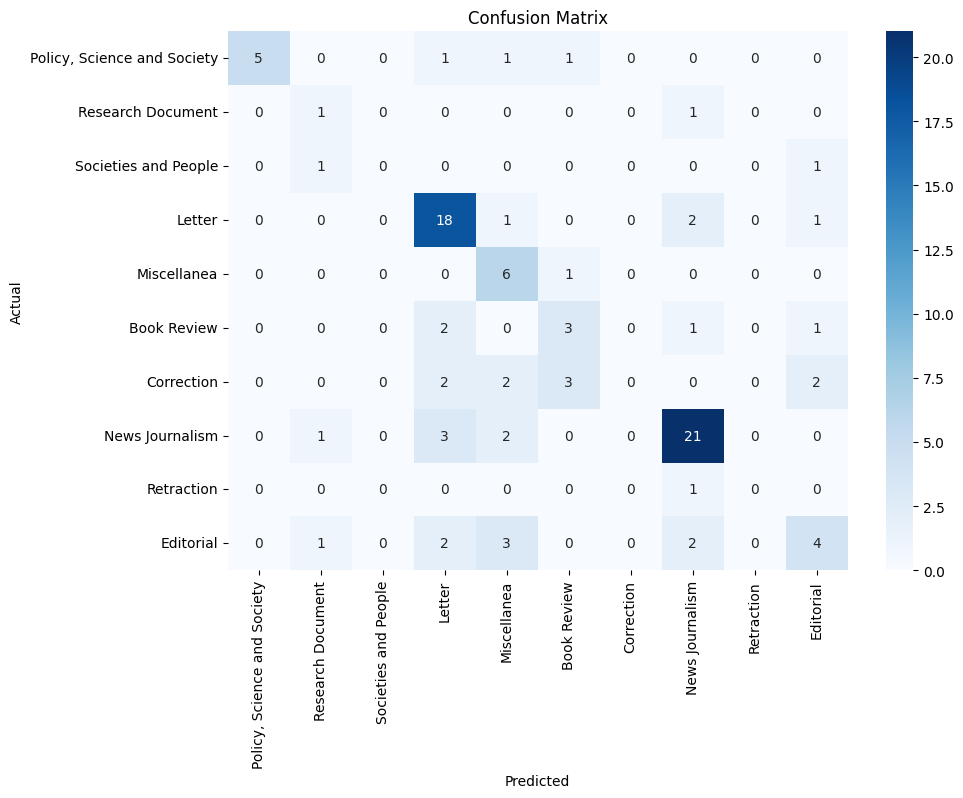

In [4]:
from setfit import SetFitModel
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_parquet('test_split2.parquet')

# Load a SetFit model
model = SetFitModel.from_pretrained("model6")

# Assuming df has a 'fullText' column for input and 'Document_subtype' for true labels
preds = model.predict(df['fullText'])

# Calculate and print evaluation metrics
print(classification_report(df['Document_subtype'], preds))

# Calculate confusion matrix
cm = confusion_matrix(df['Document_subtype'], preds)

# Visualize confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=df['Document_subtype'].unique(),
            yticklabels=df['Document_subtype'].unique())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

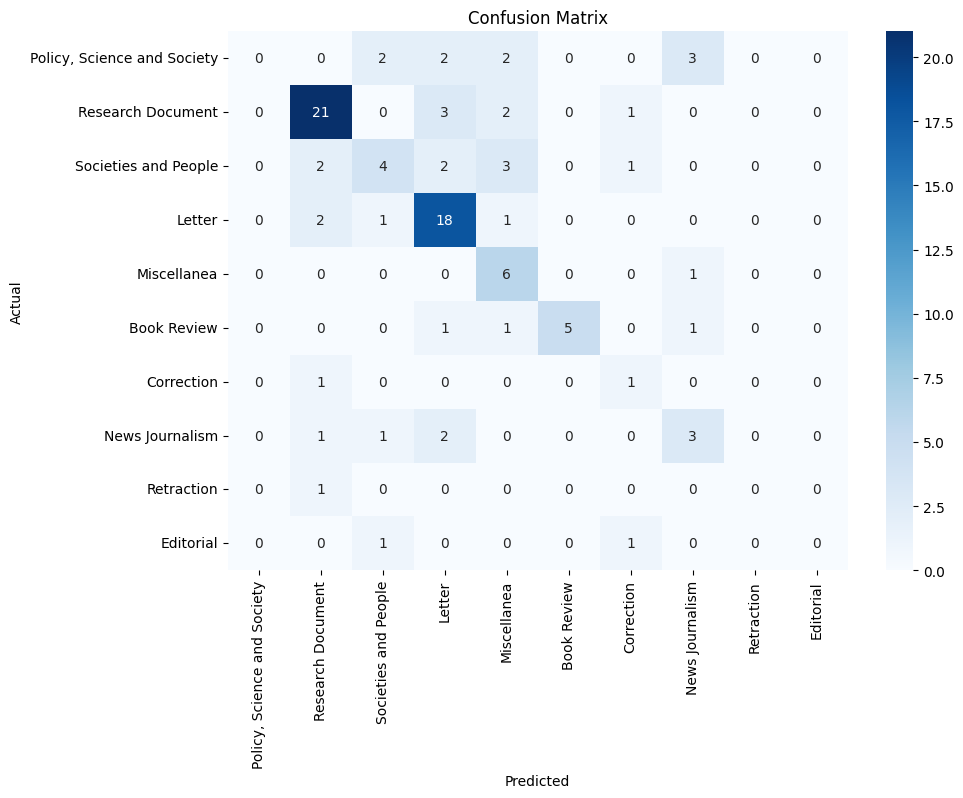

In [9]:
unique_labels = df['Document_subtype'].unique()

# Calculate confusion matrix with specified labels
cm = confusion_matrix(df['Document_subtype'], preds, labels=unique_labels)

# Visualize confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_labels,
            yticklabels=unique_labels)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# First model
Model: scincl

Train-test split: 1

Batch size: 16

Epochs: 4

Accuracy: 0.48905

In [ ]:
from datasets import load_dataset, Dataset
from setfit import SetFitModel, Trainer, TrainingArguments, sample_dataset


df = load_dataset("parquet", data_files={'train': "train_split.parquet", 'test': "test_split.parquet"})

# Load a dataset from the Hugging Face Hub
'''
train_df = load_dataset("parquet", data_files="train_split.parquet")
train_text = train_df["train"]["fullText"]
train_label = train_df["train"]["Document_subtype"]
train_data = Dataset.from_dict({ "fullText" : train_text, "Document_subtype" : train_label })

test_df = load_dataset("parquet", data_files="test_split.parquet")
test_text = test_df["train"]["fullText"]
test_label = test_df["train"]["Document_subtype"]
test_data = Dataset.from_dict({ "fullText" : test_text, "Document_subtype" : test_label })

# Simulate the few-shot regime by sampling 8 examples per class
train_dataset = sample_dataset(dataset["train"], label_column="Document_subtype")
eval_dataset = dataset["validation"].select(range(100))
test_dataset = dataset["validation"].select(range(100, len(dataset["validation"])))
'''

# Load a SetFit model from Hub
model = SetFitModel.from_pretrained(
    "malteos/scincl",
    labels=["Retraction", "Correction", "Editorial", "Policy, Science and Society", "News Journalism", "Research Document", "Letter", "Book Review", "Societies and People", "Miscellanea"],
)

args = TrainingArguments(
    batch_size=16,
    num_epochs=4,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=df['train'],
    eval_dataset=df['test'],
    metric="accuracy",
    column_mapping={"fullText": "text", "Document_subtype": "label"}  # Map dataset columns to text/label expected by trainer
)

# Train and evaluate
trainer.train()
metrics = trainer.evaluate(df['test'])
print(metrics)
# {'accuracy': 0.8691709844559585}

'''
# Push model to the Hub
trainer.push_to_hub("tomaarsen/setfit-paraphrase-mpnet-base-v2-sst2")

# Download from Hub
model = SetFitModel.from_pretrained("tomaarsen/setfit-paraphrase-mpnet-base-v2-sst2")
# Run inference
preds = model.predict(["i loved the spiderman movie!", "pineapple on pizza is the worst 🤮"])
print(preds)
# ["positive", "negative"]
'''

# Second model
Model: scincl

Train-test split: 1

Batch size: 16

Epochs: 5

Accuracy: 0.49635

In [ ]:
from datasets import load_dataset, Dataset
from setfit import SetFitModel, Trainer, TrainingArguments, sample_dataset


df = load_dataset("parquet", data_files={'train': "train_split.parquet", 'test': "test_split.parquet"})

# Load a SetFit model from Hub
model = SetFitModel.from_pretrained(
    "malteos/scincl",
    labels=["Retraction", "Correction", "Editorial", "Policy, Science and Society", "News Journalism", "Research Document", "Letter", "Book Review", "Societies and People", "Miscellanea"],
)

args = TrainingArguments(
    batch_size=16,
    num_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=df['train'],
    eval_dataset=df['test'],
    metric="accuracy",
    column_mapping={"fullText": "text", "Document_subtype": "label"}  # Map dataset columns to text/label expected by trainer
)

# Train and evaluate
trainer.train()
metrics = trainer.evaluate(df['test'])
print(metrics)
# {'accuracy': 0.8691709844559585}

model.save_pretrained("./model2")

# Third model
Model: jordyvl

Train-test split: 1

Batch size: 16

Epochs: 5

Accuracy: 0.5401459854014599

In [ ]:
from datasets import load_dataset, Dataset
from setfit import SetFitModel, Trainer, TrainingArguments, sample_dataset


df = load_dataset("parquet", data_files={'train': "train_split.parquet", 'test': "test_split.parquet"})

# Load a SetFit model from Hub
model = SetFitModel.from_pretrained(
    "jordyvl/scibert_scivocab_uncased_sentence_transformer",
    labels=["Retraction", "Correction", "Editorial", "Policy, Science and Society", "News Journalism", "Research Document", "Letter", "Book Review", "Societies and People", "Miscellanea"],
)

args = TrainingArguments(
    batch_size=16,
    num_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=df['train'],
    eval_dataset=df['test'],
    metric="accuracy",
    column_mapping={"fullText": "text", "Document_subtype": "label"}  # Map dataset columns to text/label expected by trainer
)

# Train and evaluate
trainer.train()
metrics = trainer.evaluate(df['test'])
print(metrics)
# {'accuracy': 0.8691709844559585}

model.save_pretrained("./model3")

# Fourth model
Model: jordyvl

Train-test split: 2

Batch size: 16

Epochs: 1

Accuracy: 0.5876

In [ ]:
from datasets import load_dataset, Dataset
from setfit import SetFitModel, Trainer, TrainingArguments, sample_dataset


df = load_dataset("parquet", data_files={'train': "train_split2.parquet", 'test': "test_split2.parquet"})

# Load a SetFit model from Hub
model = SetFitModel.from_pretrained(
    "jordyvl/scibert_scivocab_uncased_sentence_transformer",
    labels=["Retraction", "Correction", "Editorial", "Policy, Science and Society", "News Journalism", "Research Document", "Letter", "Book Review", "Societies and People", "Miscellanea"],
)

args = TrainingArguments(
    batch_size=16,
    num_epochs=1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=df['train'],
    eval_dataset=df['test'],
    metric="accuracy",
    column_mapping={"fullText": "text", "Document_subtype": "label"}  # Map dataset columns to text/label expected by trainer
)

# Train and evaluate
trainer.train()
metrics = trainer.evaluate(df['test'])
print(metrics)
# {'accuracy': 0.8691709844559585}

model.save_pretrained("./model4")

# Fifth model
Model: jordyvl

Train-test split: 3

Batch size: 16

Epochs: 1

Accuracy: 0.5593

In [ ]:
from datasets import load_dataset, Dataset
from setfit import SetFitModel, Trainer, TrainingArguments, sample_dataset


df = load_dataset("parquet", data_files={'train': "train_split3.parquet", 'test': "test_split3.parquet"})

# Load a SetFit model from Hub
model = SetFitModel.from_pretrained(
    "jordyvl/scibert_scivocab_uncased_sentence_transformer",
    labels=["Retraction", "Correction", "Editorial", "Policy, Science and Society", "News Journalism", "Research Document", "Letter", "Book Review", "Societies and People", "Miscellanea"],
)

args = TrainingArguments(
    batch_size=16,
    num_epochs=1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=df['train'],
    eval_dataset=df['test'],
    metric="accuracy",
    column_mapping={"fullText": "text", "Document_subtype": "label"}  # Map dataset columns to text/label expected by trainer
)

# Train and evaluate
trainer.train()
metrics = trainer.evaluate(df['test'])
print(metrics)
# {'accuracy': 0.8691709844559585}

model.save_pretrained("./model5")

# Sixth model

Model: jordyvl

Train-test split: 2

Batch size: 16

Epochs: 5

Accuracy: 0.597-0.6392

Accuracy at epoch 2: 0.56




In [ ]:
from datasets import load_dataset, Dataset
from setfit import SetFitModel, Trainer, TrainingArguments, sample_dataset


df = load_dataset("parquet", data_files={'train': "train_split2.parquet", 'test': "test_split2.parquet"})

# Load a SetFit model from Hub
model = SetFitModel.from_pretrained("jordyvl/scibert_scivocab_uncased_sentence_transformer", labels=["Retraction", "Correction", "Editorial", "Policy, Science and Society", "News Journalism", "Research Document", "Letter", "Book Review", "Societies and People", "Miscellanea"])

args = TrainingArguments(
    batch_size=16,
    num_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=df['train'],
    eval_dataset=df['test'],
    metric="accuracy",
    column_mapping={"fullText": "text", "Document_subtype": "label"}  # Map dataset columns to text/label expected by trainer
)

# Train and evaluate
trainer.train()
metrics = trainer.evaluate(df['test'])
print(metrics)
# {'accuracy': 0.8691709844559585}

model.save_pretrained("./model6")

# Other

In [ ]:
import shutil
shutil.make_archive('model6', 'zip', 'model6')
from google.colab import files
files.download('model6.zip')

In [ ]:
shutil.make_archive('checkpoints', 'zip', 'checkpoints')
from google.colab import files
files.download('checkpoints.zip')

In [ ]:
from google.colab import runtime
runtime.unassign()

In [ ]:
from setfit import SetFitModel

# Specify the path to your saved checkpoint
checkpoint_path = './checkpoint-876' # Replace with the actual path to your desired checkpoint

# Load the model from the checkpoint
loaded_model = SetFitModel.from_pretrained(checkpoint_path)
loaded_model2 = SetFitModel.from_pretrained('./FIRSTSAVE')
loaded_model3 = SetFitModel.from_pretrained("malteos/scincl")


In [ ]:
base_model = loaded_model.model_body
transformer = base_model._modules['0'].auto_model
embeddings = transformer.get_input_embeddings().weight
print(base_model)

In [ ]:
import numpy as np
doc = "The quick brown fox jumps over the lazy dog."
embedding = loaded_model.model_body.encode(doc)
embedding2 = loaded_model2.model_body.encode(doc)
embedding3 = loaded_model3.model_body.encode(doc)

print(np.dot(embedding2, embedding3)/(np.linalg.norm(embedding2)*np.linalg.norm(embedding3)))

In [ ]:
# Assuming 'loaded_model' is the name of your loaded SetFit model
# The specific layer names might vary depending on the model architecture
# You might need to inspect the model's structure to find the exact layer name

# Access the underlying Sentence Transformer model
sentence_transformer_model = loaded_model.model_body

# Access the layers of the Sentence Transformer model
# The last layer before the pooling or classification head is often the one containing the final embeddings
# You might need to adjust the index based on your specific model
# For example, if the last layer is a pooling layer, you'd look at the layer before it.
try:
    # This is a common way to access the last layer before the classification head
    # in models like those used by SetFit.
    penultimate_layer = sentence_transformer_model[1]
    print(sentence_transformer_model)

    # Access the weights of the layer
    # The way to access weights depends on the layer type (e.g., Linear, Dense)
    # If it's a Linear layer, you can typically access .weight
    print("Weights of the penultimate layer:")
    print(penultimate_layer)

except IndexError:
    print("Could not access the penultimate layer. The model might have a different structure.")
except Exception as e:
    print(f"An error occurred: {e}")